## Rolling Stone's 500 Greatest Albums of All Time: A Data Analysis

This dataset contains the Rolling Stone magazine's Top 500 Greatest Albums of All Time.
Includes rank, album title, artist, release year, genre and record label.

In this analysis, I'll explore which genres dominate, which artists appear most often, and how albums are distributed over time.


In [32]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv("rolling_stone_500.csv")

In [33]:
df.head()

,rank_no,album,artist,year,genre,record_label
0,1,What's Going On,Marvin Gaye,1971,Soul,Motown
1,2,Pet Sounds,The Beach Boys,1966,Pop,Capitol
2,3,Blue,Joni Mitchell,1971,Folk,Reprise
3,4,Songs in the Key of Life,Stevie Wonder,1976,Soul,Motown
4,5,Abbey Road,The Beatles,1969,Rock,Apple


In [34]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 6 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   rank_no       500 non-null    int64 
 1   album         500 non-null    object
 2   artist        500 non-null    object
 3   year          500 non-null    int64 
 4   genre         500 non-null    object
 5   record_label  500 non-null    object
dtypes: int64(2), object(4)
memory usage: 23.6+ KB


The dataset looks good where the release year and the rank numbers are integers and the rest are strings with no missing values.

## 1. Most Popular Genres

This chart shows the distribution of genres among the Rolling Stone's 500 Greatest Albums of All Time. To keep the data easy to visualise, only the top 18 genres are shown individually. The remaining genres are grouped into "Other", which are displayed in the legend right of the chart.

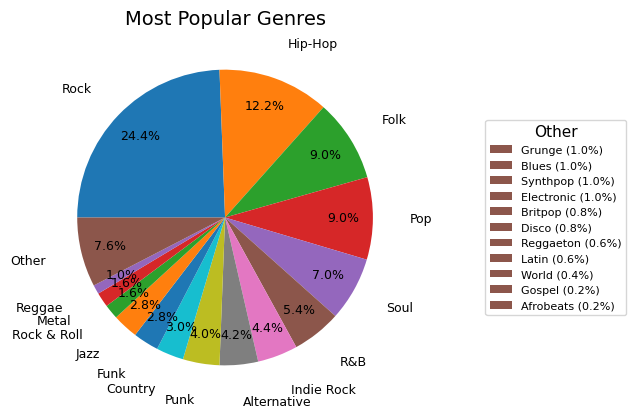

In [35]:
genre = df["genre"].value_counts()

## Splits the top 15 genres from the total
Top_Genres = genre.nlargest(15)

## Create a separate category for the remaining genres
other = genre.iloc[15:].sum()

## Add the top 15 genres with "Other" category
Most_Popular_Genres = pd.concat([Top_Genres, pd.Series([other], index=["Other"])])

## List of the genres under the "Other" category
other_list = genre.iloc[15:].index.tolist()

## Percentage of each genre
genre_counts = df["genre"].value_counts(normalize=True) * 100 

## Percentage of all the "Other" genres
other_percentages=genre_counts.loc[other_list]

## Plot the pie chart
wedges, texts, autotexts = plt.pie(
    Most_Popular_Genres,
    labels=Most_Popular_Genres.index,
    autopct="%1.1f%%",
    startangle=180,
    counterclock=False,
    pctdistance=0.8,
    labeldistance=1.25,
    textprops={"fontsize": 9}
)

## Get the colour of the "Other" slice
other_colour = wedges[-1].get_facecolor()

## Create legend handles for all "Other" genres
handles = [plt.Rectangle((0,0), 1, 1, facecolor=other_colour) for _ in other_list]

## Formats the labels as "[genre] (x.x%)"
labels_with_pct = [f"{genre} ({pct:.1f}%)" for genre, pct in other_percentages.items()]

## Add a legend of the genres listed as "Other" with their respective percentages
plt.legend(
    handles=handles,
    labels=labels_with_pct,
    title="Other",
    title_fontsize=11,
    fontsize=8,
    loc="center right",
    bbox_to_anchor=(1.1, 0, 0.5, 1)
)

plt.ylabel("")
plt.title("Most Popular Genres", fontsize=14)
plt.show()

##### Summary:
Rock is the dominant genre, with a significant representation from Hip-Hop, Folk, Pop and Soul.

## 2. Most Featured Artists

This chart displays the artists that appear the most frequent on the Rolling Stone's 500 Greatest Albums of All Time list. The top 10 most featured artists are shown in a horizontal bar chart along with the value of their appearances. 

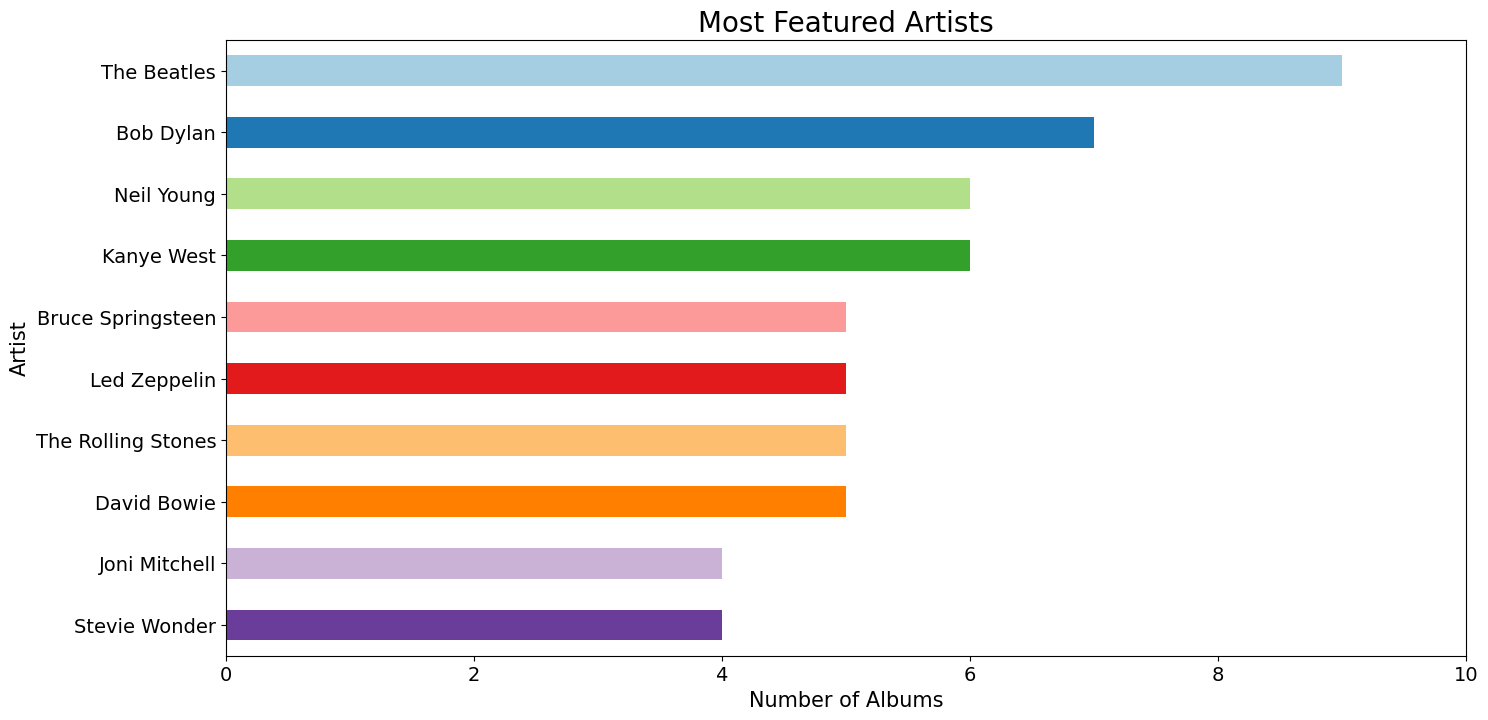

In [36]:
## Plot the horizontal bar chart
plt.figure(figsize=(16,8))
df["artist"].value_counts().head(10).plot(kind="barh", color=plt.cm.Paired.colors, fontsize=14)

## Titles and axis labels
plt.title("Most Featured Artists", fontsize=20)
plt.xlabel("Number of Albums", fontsize=15)
plt.ylabel("Artist", fontsize=15)

## Puts the highest artist at the top
plt.gca().invert_yaxis()
plt.xlim(0, 10)
plt.show()

##### Summary:
The Beatles and Bob Dylan dominate the rankings, highlighting their ever-lasting influence on modern music.

## 3. Albums by Decade
To examine trends over time, I grouped release years into decades. This chart shows how many albums from each decade made it onto the Top 500 list.

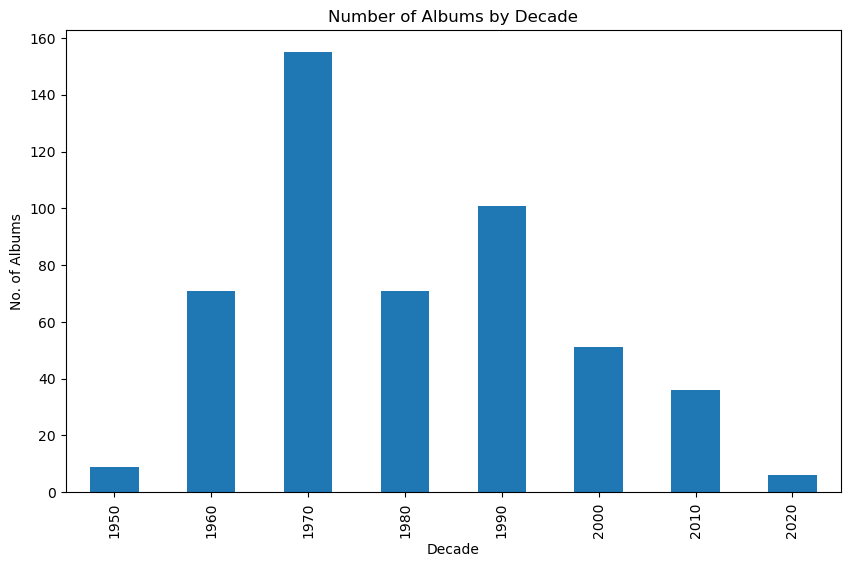

In [37]:
df["Decade"] = (df["year"] // 10) * 10
df["Decade"].value_counts().sort_index().plot(kind="bar", figsize=(10,6))
plt.title("Number of Albums by Decade")
plt.ylabel("No. of Albums")
plt.xlabel("Decade")
plt.show()

##### Summary:
The 1970s stand out as the most represented decade, reflecting the era’s creative influence. By comparison, the 21st century contributes far fewer albums to the list.

## 4. Albums per Record Label by Decade
This chart shows the distribution of albums from the Rolling Stone Top 500 Greatest Albums across record labels over different decades. Each stacked bar represents a decade, with segments indicating the number of albums released by each of the top record labels.

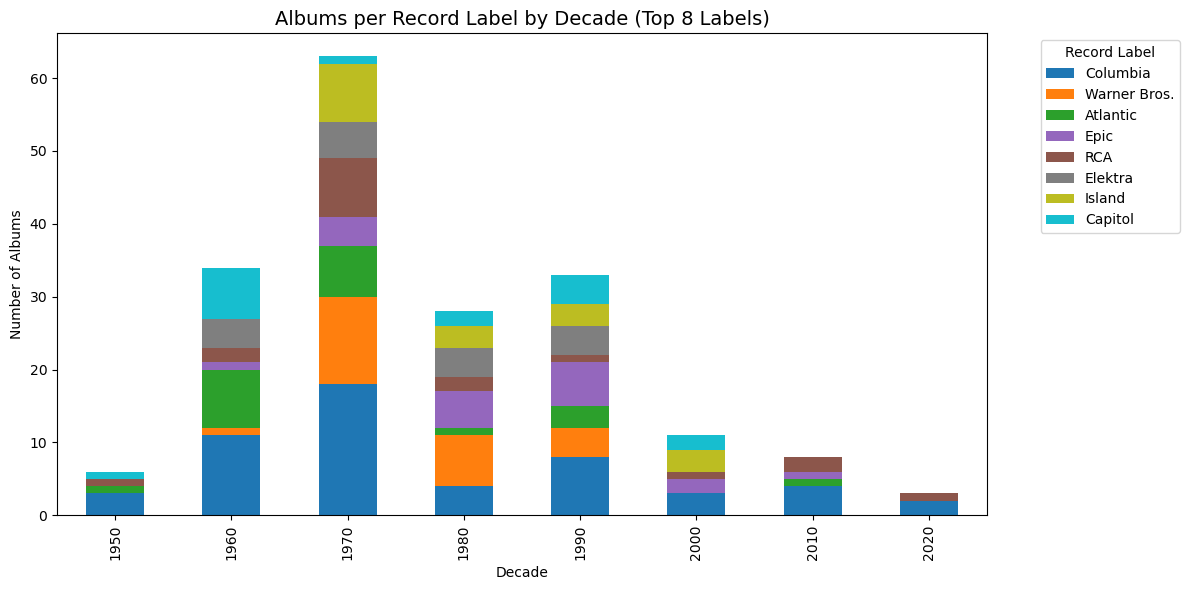

In [38]:
label_decade_counts = df.pivot_table(
    index='Decade',
    columns='record_label',
    aggfunc='size',
    fill_value=0
)

top_labels = df['record_label'].value_counts().head(8).index
label_decade_counts = label_decade_counts[top_labels]

label_decade_counts.plot(
    kind='bar',      
    stacked=True,    
    figsize=(12,6),
    colormap='tab10'   
)

plt.xlabel("Decade")
plt.ylabel("Number of Albums")
plt.title("Albums per Record Label by Decade (Top 8 Labels)", fontsize=14)
plt.legend(title='Record Label', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

##### Summary:
Columbia and RCA remain prevalent throughout every decade, while Warner Bros. and Atlantic Records declined in the 21st century after being dominant in earlier decades.

## Conclusion
Rock dominates the Top 500 list, The Beatles and Bob Dylan feature the most, the 1970s are the decade most represented and Columbia Records hold the most of the 500 greatest albums.

This analysis really provides a snapshot of the Rolling Stone's Top 500 Greatest Albums of All Time and its trends. 
Future analysis could compare this list to today's streaming data to see if this correlates to what people listen to.